<a href="https://colab.research.google.com/github/DiegoVilla3/JHU-Diego/blob/main/Prog_Heatmaps_R_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python Segment

## Basic Time Series Heatmap and Clustering Heatmap

### Seaborn resource website: https://seaborn.pydata.org/

In [ ]:
import pandas as pd
import seaborn as sns  ## Used to construct the heatmap
import matplotlib.pyplot as plt ## Used to place the titles, the dimensions and to show the graph
import numpy as np

# Sample Data (replace with your own)
np.random.seed(42)
data = np.random.rand(10, 5)
df = pd.DataFrame(data, columns=['Sample1', 'Sample2', 'Sample3', 'Sample4', 'Sample5'],
                  index=['GeneA', 'GeneB', 'GeneC', 'GeneD', 'GeneE', 'GeneF', 'GeneG', 'GeneH', 'GeneI', 'GeneJ'])

# Basic Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df, cmap='viridis', annot=True, fmt=".2f") # annot adds data values
plt.title('Basic Heatmap')
plt.show()


# Clustering Heatmap
plt.figure(figsize=(8, 6))
sns.clustermap(df, cmap='magma', metric="correlation", standard_scale=1) #standard_scale=1 to normalize
plt.title('Clustering Heatmap')
plt.show()


ERROR: Error in parse(text = input): <text>:1:8: unexpected symbol
1: import pandas
           ^


## Loading the data using an excel file

In [ ]:
# Now lets load the data using an excel format!

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get the Excel file path from the user
excel_file = input("Enter the path to your Excel file: ")

# Get the sheet name from the user
sheet_name = input("Enter the sheet name: ")

# Read the Excel file into a pandas DataFrame
df = pd.read_excel(excel_file, sheet_name=sheet_name)

# Get the column names for gene expression and gene names from the user
gene_expression_col = input("Enter the column name for gene expression: ")
gene_names_col = input("Enter the column name for gene names: ")

# Isolate the relevant data
gene_expression_data = df[[gene_names_col, gene_expression_col]]
gene_expression_data = gene_expression_data.set_index(gene_names_col)

# Create the heatmap
plt.figure(figsize=(10, 8))  # Adjust figure size as needed
sns.heatmap(gene_expression_data, cmap='viridis', annot=True, fmt=".2f")
plt.title('Gene Expression Heatmap') # you can also use the str(input()) code to enter your new title
plt.xlabel(gene_expression_col)
plt.ylabel(gene_names_col)
plt.show()


# R Segment
## Basic Time Series Heatmap and Clustering Heatmap
### pHeatmap resource website: https://rdrr.io/cran/pheatmap/src/R/pheatmap.r

# Case 1: Gene expression is random

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "Assuming you have produced dorsal frontal organoids of 3 patients using iPSCs and created transcriptome assemblies."
[1] "You have averaged out the expression profiles of these organoids and produced the heatmaps. Genes1-10 are measured. "


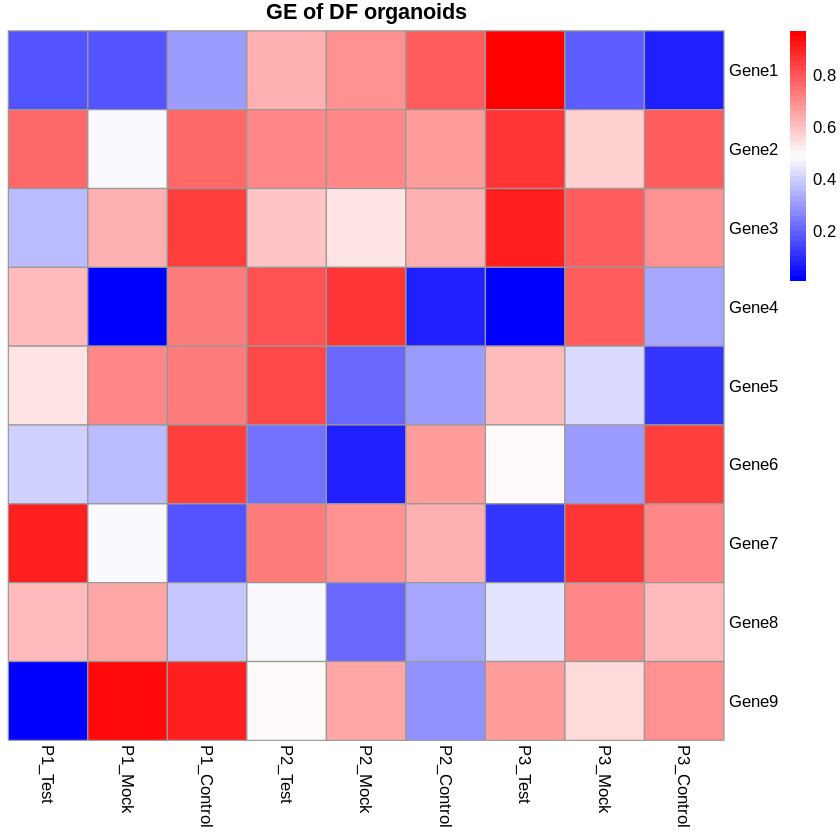

ERROR: Error in `.rowNamesDF<-`(x, value = value): invalid 'row.names' length


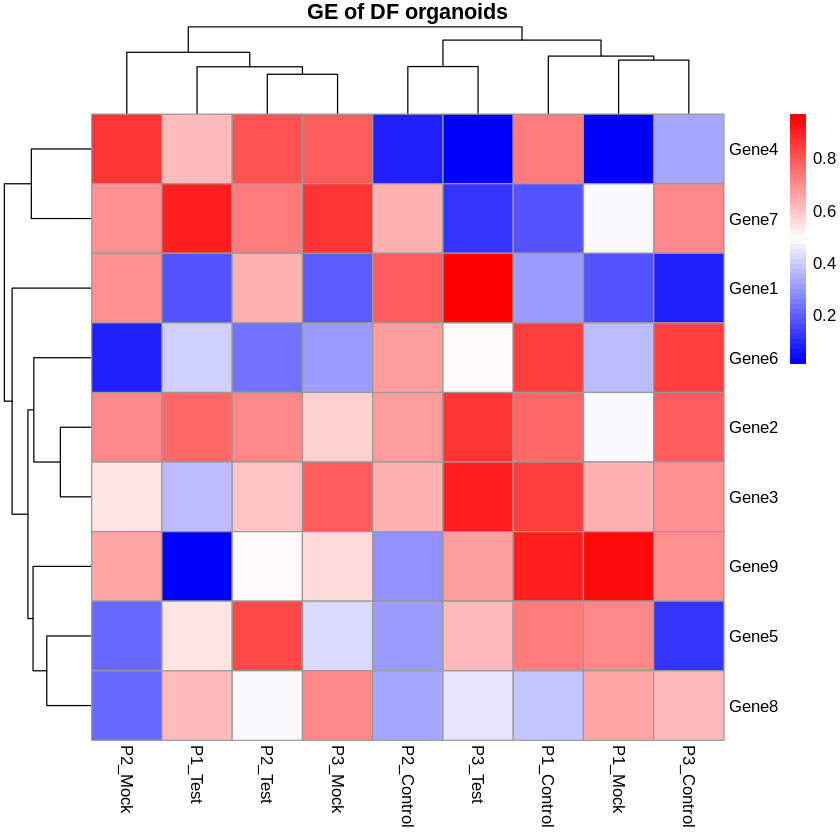

In [ ]:
install.packages("pheatmap")
library(pheatmap)

print("Assuming you have produced dorsal frontal organoids of 3 patients using iPSCs and created transcriptome assemblies.")
print("You have averaged out the expression profiles of these organoids and produced the heatmaps. Genes1-10 are measured. ")

# Sample data (Replace with your own)
data <- matrix(runif(81), nrow=9)
rownames(data) <- paste0("Gene", 1:9)

# Define patients and conditions
patients <- paste0("P", 1:3)
conditions <- c("Test", "Mock", "Control")

# Generate column names
colnames(data) <- paste(rep(patients, each = length(conditions)), conditions, sep = "_")

# Basic Heatmap
bh1 <- pheatmap(data, main = "GE of DF organoids", color = colorRampPalette(c("blue", "white", "red"))(50), cluster_rows = FALSE, cluster_cols = FALSE)

# Clustering Heatmap
ch1 <- pheatmap(data, main = "GE of DF organoids", color = colorRampPalette(c("blue", "white", "red"))(50), cluster_rows = TRUE, cluster_cols = TRUE)

## Exploring the clustering data within the global variable

Gene1 Gene2 Gene3 Gene4 Gene5 Gene6 Gene7 Gene8 Gene9 
    1     1     1     2     1     1     2     1     1 
   P1_Test    P1_Mock P1_Control    P2_Test    P2_Mock P2_Control    P3_Test 
         1          2          2          1          1          3          3 
   P3_Mock P3_Control 
         1          2 


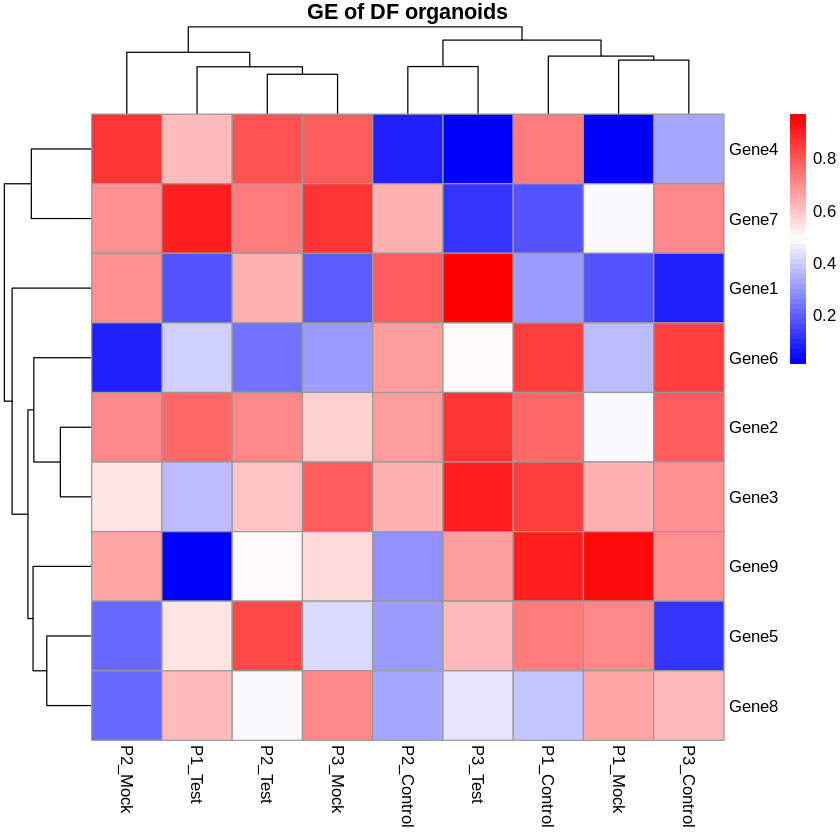

In [ ]:
print(ch1)

# Access cluster information for rows
row_clusters <- ch1$tree_row

# Access cluster information for columns
col_clusters <- ch1$tree_col

# Extract cluster assignments for rows (e.g., into 2 clusters)
row_assignments <- cutree(row_clusters, k = 2)

# Extract cluster assignments for columns (e.g., into 3 clusters)
col_assignments <- cutree(col_clusters, k = 3)

# Print the cluster assignments
print(row_assignments)
print(col_assignments)

# Case 2: Gene expression can be traced with correlation

In [ ]:
install.packages("pheatmap")
library(pheatmap)

print("Assuming you have produced dorsal frontal organoids of 3 patients using iPSCs and created transcriptome assemblies.")
print("You have averaged out the expression profiles of these organoids and produced the heatmaps. Genes1-10 are measured. ")

# Sample data (Replace with your own)
data <- matrix(runif(81), nrow=9)
rownames(data) <- paste0("Gene", 1:9)

# Define patients and conditions
patients <- paste0("P", 1:3)
conditions <- c("Test", "Mock", "Control")

# Generate column names
colnames(data) <- paste(rep(patients, each = length(conditions)), conditions, sep = "_")

# Manually increase expression for Gene1 and Gene2 in Test samples
test_cols <- grep("Test", colnames(data))  # Indices of Test condition columns

# Set higher values (e.g., between 0.8 and 1) for Gene1 and Gene2 in Test
data[1, test_cols] <- runif(length(test_cols), min = 0.8, max = 1)   # Gene1
data[2, test_cols] <- runif(length(test_cols), min = 0.8, max = 1)   # Gene2


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "Assuming you have produced dorsal frontal organoids of 3 patients using iPSCs and created transcriptome assemblies."
[1] "You have averaged out the expression profiles of these organoids and produced the heatmaps. Genes1-10 are measured. "


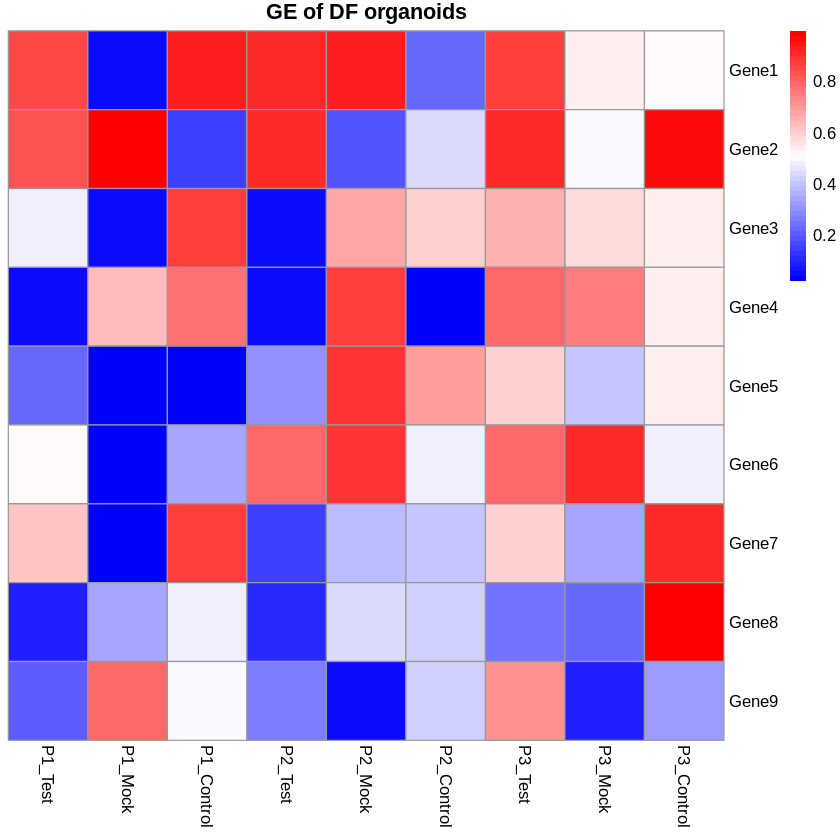

ERROR: Error in `.rowNamesDF<-`(x, value = value): invalid 'row.names' length


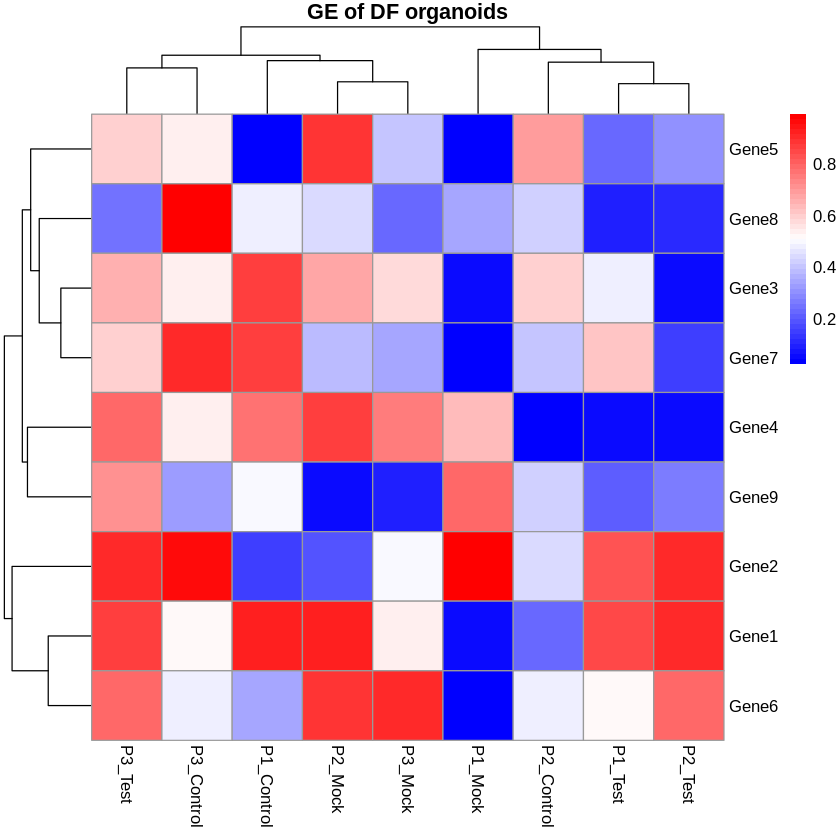

In [ ]:
# Basic Heatmap
bh2 <- pheatmap(data, main = "GE of DF organoids",
          color = colorRampPalette(c("blue", "white", "red"))(50), cluster_rows = FALSE, cluster_cols = FALSE)

# Clustering Heatmap
ch2 <- pheatmap(data, main = "GE of DF organoids",
          color = colorRampPalette(c("blue", "white", "red"))(50), cluster_rows = TRUE, cluster_cols = TRUE)

## Exploring the clustering data within the global variable

Gene1 Gene2 Gene3 Gene4 Gene5 Gene6 Gene7 Gene8 Gene9 
    1     1     2     2     2     1     2     2     2 
   P1_Test    P1_Mock P1_Control    P2_Test    P2_Mock P2_Control    P3_Test 
         1          2          3          1          3          1          3 
   P3_Mock P3_Control 
         3          3 


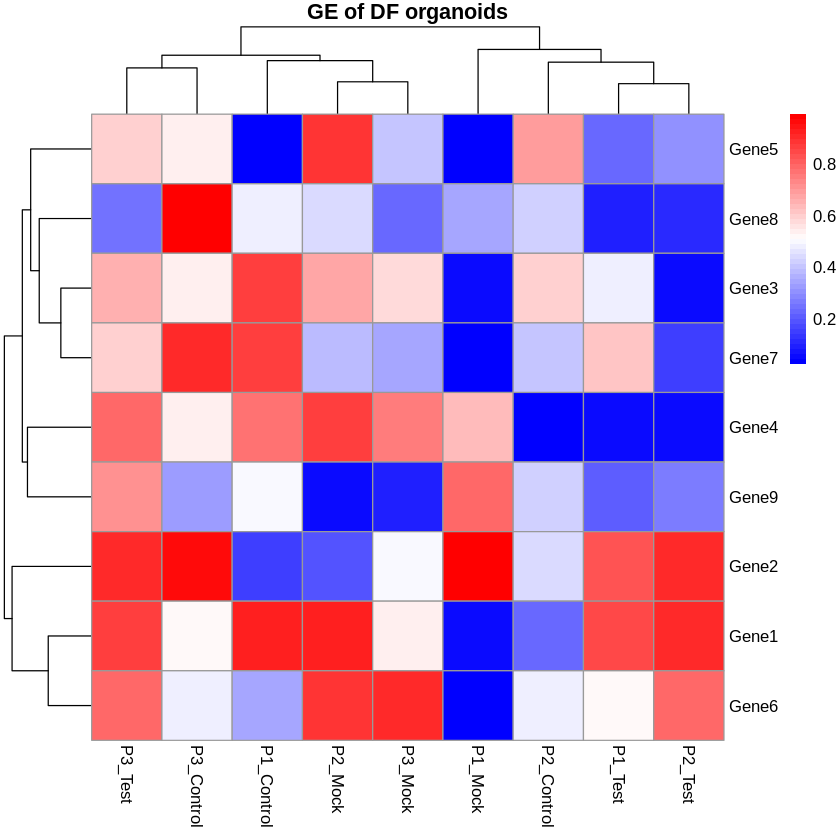

In [ ]:
print(ch2)

# Access cluster information for rows
row_clusters <- ch2$tree_row

# Access cluster information for columns
col_clusters <- ch2$tree_col

# Extract cluster assignments for rows (e.g., into 2 clusters)
row_assignments <- cutree(row_clusters, k = 2)

# Extract cluster assignments for columns (e.g., into 3 clusters)
col_assignments <- cutree(col_clusters, k = 3)

# Print the cluster assignments
print(row_assignments)
print(col_assignments)

In [ ]:
# Now lets load the data using an excel format!

# Install pheatmap if you haven't already
if(!require("pheatmap")){
  install.packages("pheatmap")
}
library(pheatmap)

# Get the Excel file path from the user
excel_file <- readline(prompt="Enter the path to your Excel file: ")

# Get the sheet name from the user
sheet_name <- readline(prompt="Enter the sheet name: ")

# Read the Excel file into a data frame
# Install readxl if you haven't already
if(!require("readxl")){
  install.packages("readxl")
}
library(readxl)
data <- read_excel(excel_file, sheet = sheet_name)

# Get the column names for gene expression and gene names from the user
gene_expression_col <- readline(prompt="Enter the column name for gene expression: ")
gene_names_col <- readline(prompt="Enter the column name for gene names: ")

# Isolate the relevant data
gene_expression_data <- data[, c(gene_names_col, gene_expression_col)]
rownames(gene_expression_data) <- gene_expression_data[[gene_names_col]]
gene_expression_data <- gene_expression_data[, gene_expression_col, drop = FALSE]

# Create the heatmap
pheatmap(gene_expression_data,
         color = colorRampPalette(c("blue", "white", "red"))(50),
         cluster_rows = TRUE,
         cluster_cols = TRUE,
         main = "Gene Expression Heatmap")

# Key Similarities between both tools

## Title and Display Handling:

1. pheatmap (R) allows you to directly assign a title using the main parameter and handles visualization with built-in support for showing the heatmap in RStudio.

2. seaborn.heatmap (Python) does not have a dedicated parameter for setting the title; titles must be added manually using matplotlib.pyplot.title(). Also, display behavior depends on the Python environment (e.g., Jupyter vs. script).

## Clustering Capabilities:

1. Seaborn supports clustering via hierarchical clustering on a correlation matrix or via libraries like scipy.cluster.hierarchy when building a clustermap (seaborn.clustermap).

2. pheatmap provides built-in support for hierarchical clustering on rows and/or columns using the cluster_rows and cluster_cols parameters (TRUE/FALSE), but does not support correlation matrix input directly for clustering.

# Key Differences between both tools

## Heatmap Visualization:
 - Both seaborn.heatmap/clustermap and pheatmap are used to generate 2D heatmaps with color gradients to represent data intensities.

## Annotation Options:
 - Both tools support cell-level annotations (numbers in the heatmap cells) — annot=True in Seaborn, and display_numbers=TRUE in pheatmap.

## Color Customization:
 - Each allows for customization of the color palette — Seaborn via the cmap parameter, and pheatmap via the color parameter.

## Support for Dendrograms (when clustering):
 - When clustering is applied, both can render dendrograms to visualize hierarchical relationships — Seaborn through clustermap, and pheatmap through its own clustering logic.

## Integration with Data Frames:
 - Both tools accept data frames as input and are commonly used with expression data (e.g., gene expression matrices).

# Thank you for attending this workshop!
## Please fill out the following form to provide your feedback. It takes less than 5 minutes! https://docs.google.com/forms/d/1HoIGwIS8YkXoVd4hFYvP0h5hlGQf-8L88pvZlu7Vi2g/edit

# Next Workshops!
1. Working with BLAST in STEM
2. Modular Approaches for Student Learning
3. Using Protein-Ligand prediction tools